# 📊 Exploratory Data Analysis
This ipython notebook focuses on combining and understanding the calories and exercise datasets to get insights about the data and preparing for model evaluation.

In [1]:
# Importing necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Loading dataframes
calories = pd.read_csv("calories.csv")
exercise = pd.read_csv("exercise.csv")

In [3]:
# Joining the exercise and calories tables/dataframes
data = pd.merge(exercise, calories, on = "User_ID", how = "outer")

In [4]:
data

,User_ID,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
0,10001159,female,67,176.0,74.0,12.0,103.0,39.6,76.0
1,10001607,female,34,178.0,79.0,19.0,96.0,40.6,93.0
2,10005485,female,38,178.0,77.0,14.0,82.0,40.5,49.0
3,10005630,female,39,169.0,66.0,8.0,90.0,39.6,36.0
4,10006441,male,23,169.0,73.0,25.0,102.0,40.7,122.0
...,...,...,...,...,...,...,...,...,...
14995,19999044,female,25,169.0,66.0,22.0,105.0,40.6,129.0
14996,19999086,female,31,170.0,69.0,9.0,93.0,39.8,42.0
14997,19999257,male,21,176.0,75.0,19.0,109.0,40.5,112.0
14998,19999394,female,36,152.0,54.0,10.0,86.0,39.7,42.0


In [5]:
# Dropping "User_ID" column bcoz its useless
data = data.drop("User_ID", axis = 1)

In [6]:
data

,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
0,female,67,176.0,74.0,12.0,103.0,39.6,76.0
1,female,34,178.0,79.0,19.0,96.0,40.6,93.0
2,female,38,178.0,77.0,14.0,82.0,40.5,49.0
3,female,39,169.0,66.0,8.0,90.0,39.6,36.0
4,male,23,169.0,73.0,25.0,102.0,40.7,122.0
...,...,...,...,...,...,...,...,...
14995,female,25,169.0,66.0,22.0,105.0,40.6,129.0
14996,female,31,170.0,69.0,9.0,93.0,39.8,42.0
14997,male,21,176.0,75.0,19.0,109.0,40.5,112.0
14998,female,36,152.0,54.0,10.0,86.0,39.7,42.0


In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Gender      15000 non-null  object 
 1   Age         15000 non-null  int64  
 2   Height      15000 non-null  float64
 3   Weight      15000 non-null  float64
 4   Duration    15000 non-null  float64
 5   Heart_Rate  15000 non-null  float64
 6   Body_Temp   15000 non-null  float64
 7   Calories    15000 non-null  float64
dtypes: float64(6), int64(1), object(1)
memory usage: 937.6+ KB


In [8]:
data.describe()

,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,42.789800,174.465133,74.966867,15.530600,95.518533,40.025453,89.539533
std,16.980264,14.258114,15.035657,8.319203,9.583328,0.779230,62.456978
min,20.000000,123.000000,36.000000,1.000000,67.000000,37.100000,1.000000
25%,28.000000,164.000000,63.000000,8.000000,88.000000,39.600000,35.000000
50%,39.000000,175.000000,74.000000,16.000000,96.000000,40.200000,79.000000
75%,56.000000,185.000000,87.000000,23.000000,103.000000,40.600000,138.000000
max,79.000000,222.000000,132.000000,30.000000,128.000000,41.500000,314.000000


In [9]:
# Male vs female count
data["Gender"].value_counts()

Gender
female    7553
male      7447
Name: count, dtype: int64

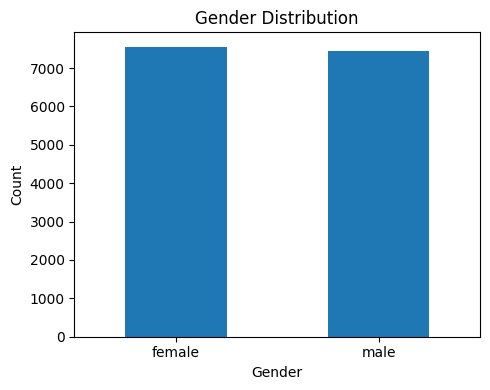

In [10]:
data["Gender"].value_counts().plot(
    kind="bar",
    figsize=(5,4)
)

plt.title("Gender Distribution")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

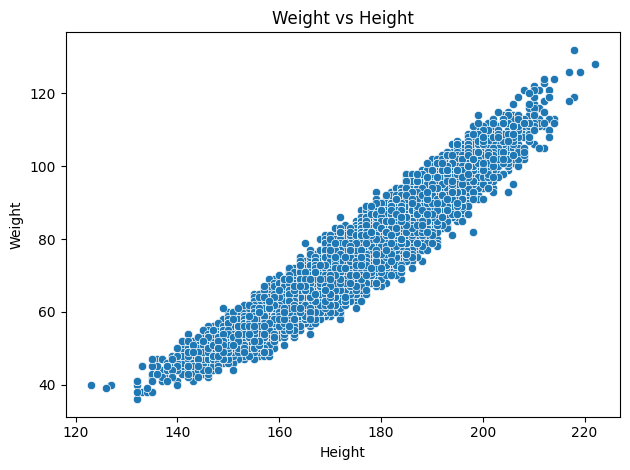

In [11]:
# Weight vs Height scatterplot for each person
sns.scatterplot(x='Height', y='Weight', data=data) 
plt.title("Weight vs Height")
plt.tight_layout()

In [12]:
data

,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
0,female,67,176.0,74.0,12.0,103.0,39.6,76.0
1,female,34,178.0,79.0,19.0,96.0,40.6,93.0
2,female,38,178.0,77.0,14.0,82.0,40.5,49.0
3,female,39,169.0,66.0,8.0,90.0,39.6,36.0
4,male,23,169.0,73.0,25.0,102.0,40.7,122.0
...,...,...,...,...,...,...,...,...
14995,female,25,169.0,66.0,22.0,105.0,40.6,129.0
14996,female,31,170.0,69.0,9.0,93.0,39.8,42.0
14997,male,21,176.0,75.0,19.0,109.0,40.5,112.0
14998,female,36,152.0,54.0,10.0,86.0,39.7,42.0


In [13]:
# Encoding male as 0 and female as 1
data["Gender"] = data["Gender"].map({"male": 0, "female": 1})

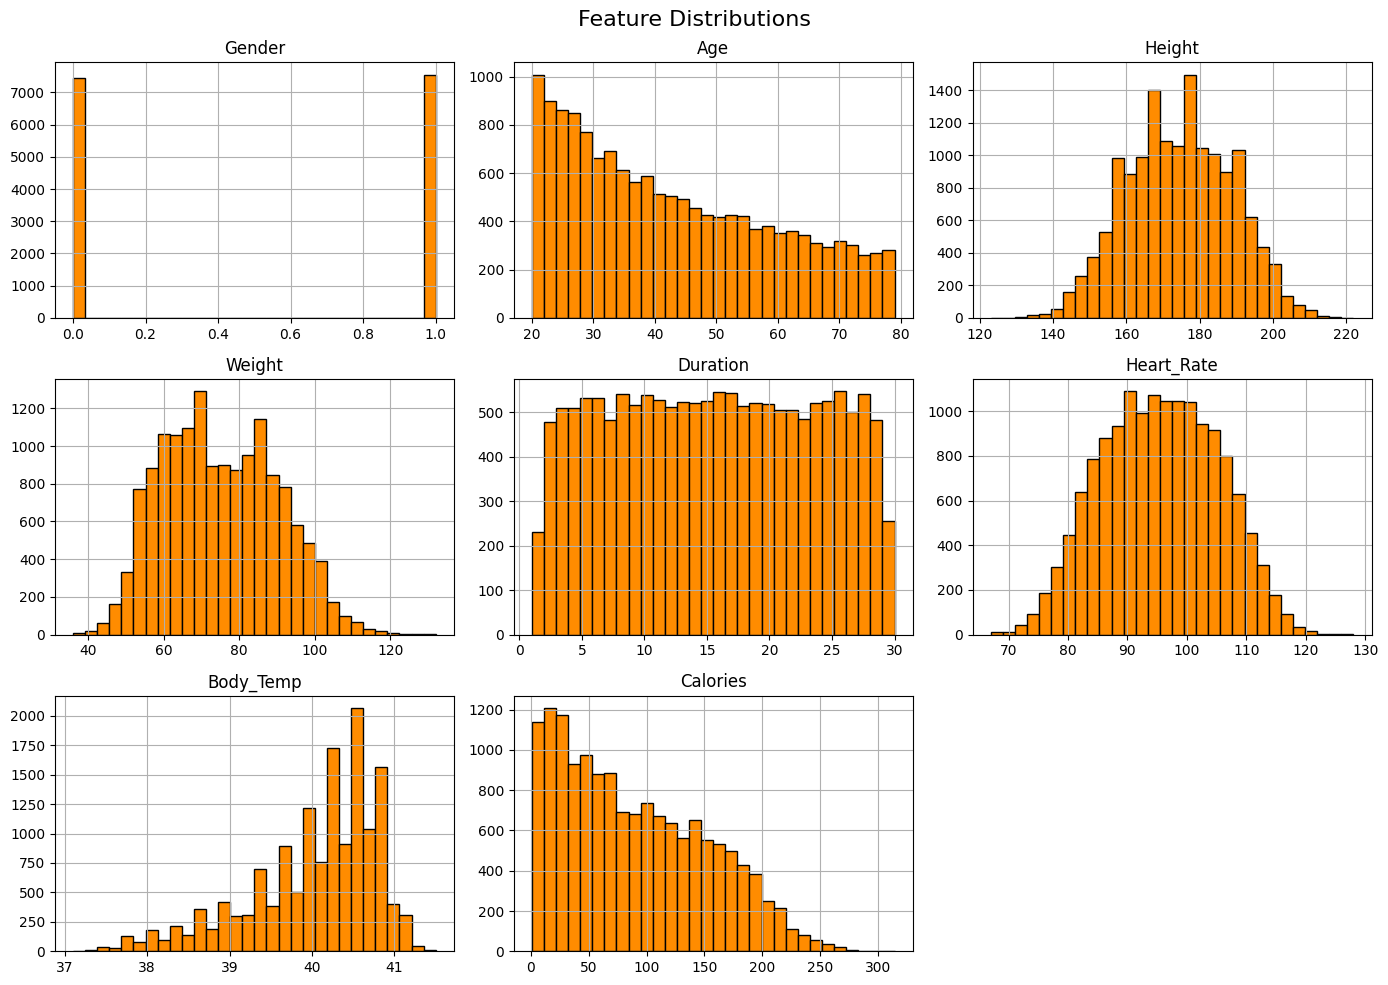

In [14]:
# Finding features distribution
data.hist(figsize=(14,10), bins=30, color="darkorange", edgecolor="black")
plt.suptitle("Feature Distributions", fontsize = 16)
plt.tight_layout()
plt.show()

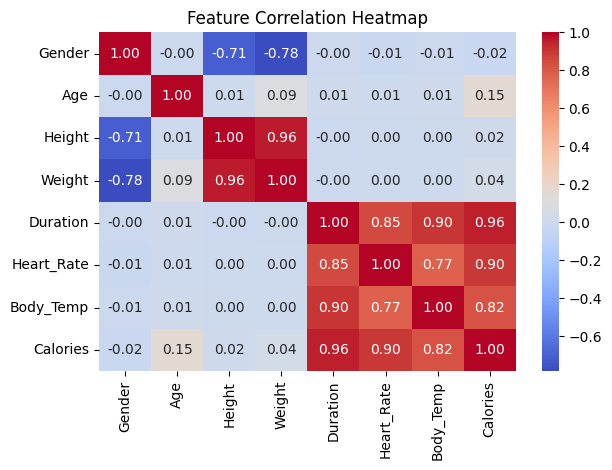

In [15]:
# Finding features correlation
corr = data.corr()

sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

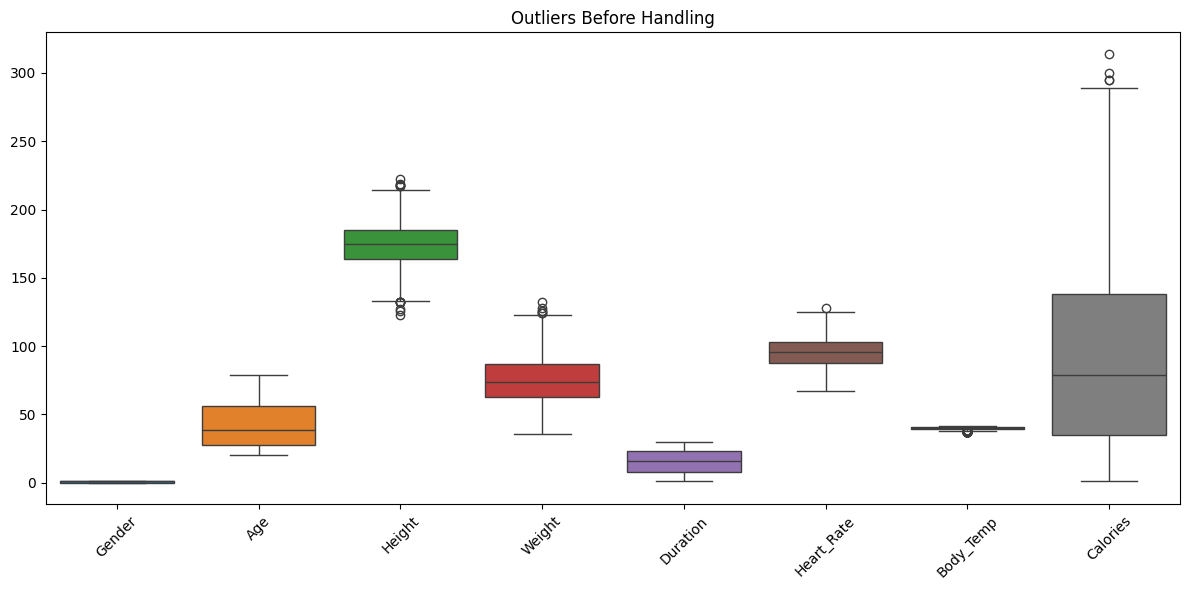

In [16]:
# Checking for outliers
plt.figure(figsize=(12,6))
sns.boxplot(data=data)
plt.xticks(rotation=45)
plt.title("Outliers Before Handling")
plt.tight_layout()
plt.show()

In [17]:
# Making a copy of data for outlier handling
df = data.copy()

In [18]:
# Outliers handling using the Inter Quantile Range Method

def iqr_clip(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df[col] = df[col].clip(lower, upper)

for col in df.columns:
    iqr_clip(df, col)

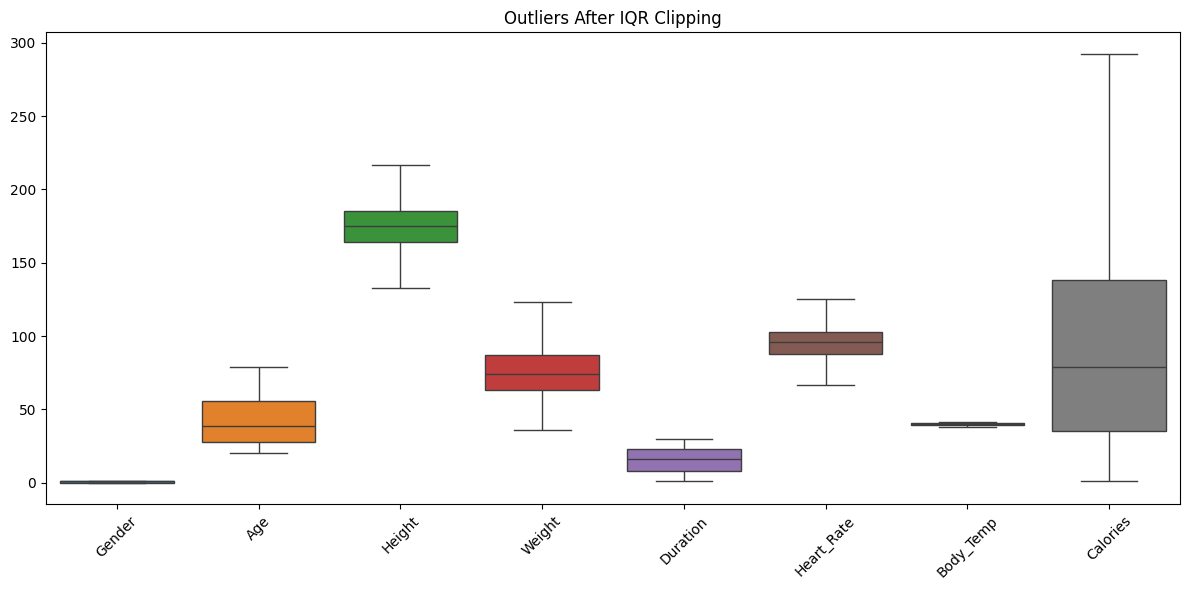

In [19]:
# Dataset without outliers
plt.figure(figsize=(12,6))
sns.boxplot(data=df)
plt.xticks(rotation=45)
plt.title("Outliers After IQR Clipping")
plt.tight_layout()
plt.show()

In [20]:
df

,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
0,1,67,176.0,74.0,12.0,103.0,39.6,76.0
1,1,34,178.0,79.0,19.0,96.0,40.6,93.0
2,1,38,178.0,77.0,14.0,82.0,40.5,49.0
3,1,39,169.0,66.0,8.0,90.0,39.6,36.0
4,0,23,169.0,73.0,25.0,102.0,40.7,122.0
...,...,...,...,...,...,...,...,...
14995,1,25,169.0,66.0,22.0,105.0,40.6,129.0
14996,1,31,170.0,69.0,9.0,93.0,39.8,42.0
14997,0,21,176.0,75.0,19.0,109.0,40.5,112.0
14998,1,36,152.0,54.0,10.0,86.0,39.7,42.0


In [21]:
df.describe()

,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,0.503533,42.789800,174.465933,74.965400,15.530600,95.518367,40.033207,89.537267
std,0.500004,16.980264,14.250563,15.030691,8.319203,9.582785,0.757570,62.449328
min,0.000000,20.000000,132.500000,36.000000,1.000000,67.000000,38.100000,1.000000
25%,0.000000,28.000000,164.000000,63.000000,8.000000,88.000000,39.600000,35.000000
50%,1.000000,39.000000,175.000000,74.000000,16.000000,96.000000,40.200000,79.000000
75%,1.000000,56.000000,185.000000,87.000000,23.000000,103.000000,40.600000,138.000000
max,1.000000,79.000000,216.500000,123.000000,30.000000,125.500000,41.500000,292.500000


In [22]:
data.describe()

,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,0.503533,42.789800,174.465133,74.966867,15.530600,95.518533,40.025453,89.539533
std,0.500004,16.980264,14.258114,15.035657,8.319203,9.583328,0.779230,62.456978
min,0.000000,20.000000,123.000000,36.000000,1.000000,67.000000,37.100000,1.000000
25%,0.000000,28.000000,164.000000,63.000000,8.000000,88.000000,39.600000,35.000000
50%,1.000000,39.000000,175.000000,74.000000,16.000000,96.000000,40.200000,79.000000
75%,1.000000,56.000000,185.000000,87.000000,23.000000,103.000000,40.600000,138.000000
max,1.000000,79.000000,222.000000,132.000000,30.000000,128.000000,41.500000,314.000000


In [23]:
# Saving the datasets
data = data.to_csv("data_with_outliers.csv")
df = df.to_csv("data_without_outliers.csv")